## Import libs

In [1]:
from sklearn.model_selection import train_test_split
import seaborn as sns

from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset

from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.vanilla_lr.model import VanillaLogisticRegression
from falsb4mpa.modeling.vanilla_lr.learning import train_loop

from falsb4mpa.evaluation.evaluation import evaluation

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.0001
opt = Adam(learning_rate=learning_rate)

In [3]:
cv_seeds = [13]
# cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

97 1 1 1 8


## Result file

In [7]:
header = "model_name", "cv_seed", "clas_acc", "a1_dp", "a1_deqodds", "a1_deqopp", "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", "a0_dp", "a0_deqodds", "a0_deqopp", "a0_TN_g0", "a0_FP_g0", "a0_FN_g0", "a0_TP_g0", "a0_TN_g1", "a0_FP_g1", "a0_FN_g1", "a0_TP_g1"

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        
        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)
        
        model = VanillaLogisticRegression(xdim, ydim, batch_size)
        ret = train_loop(model, train_data, epochs)
        
        Y, A1, A2, Y_hat = evaluation(model, test_data)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(Y, A2, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['VanillaLR', cv_seed, clas_acc, a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

> Epoch | Class Loss | Class Acc


2026-05-05 10:37:08.642698: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 1 | 0.47688028216362 | 0.6151632085020243


2026-05-05 10:37:10.386877: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 2 | 0.4122905433177948 | 0.7887778340080972
> 3 | 0.39054590463638306 | 0.8121204453441295


...

> 16 | 0.35081273317337036 | 0.8284412955465587
> 17 | 0.35005661845207214 | 0.8288841093117408
> 18 | 0.34936439990997314 | 0.8290106275303644
> 19 | 0.3487272262573242 | 0.8292320344129555
> 20 | 0.3481377363204956 | 0.8293901821862348
> 21 | 0.347589910030365 | 0.8295167004048583
> 22 | 0.3470788598060608 | 0.8297697368421053
> 23 | 0.3466002941131592 | 0.8298646255060729
> 24 | 0.34615087509155273 | 0.8299278846153846
> 25 | 0.34572750329971313 | 0.8300544028340081
> 26 | 0.34532755613327026 | 0.8302758097165992
> 27 | 0.344948947429657 | 0.8304339574898786
> 28 | 0.34458959102630615 | 0.8304972165991903
> 29 | 0.3442479372024536 | 0.8303706983805668
> 30 | 0.34392234683036804 | 0.8305288461538461
> 31 | 0.34361153841018677 | 0.830560475708502


2026-05-05 10:38:03.366911: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 32 | 0.34331443905830383 | 0.8306553643724697
> 33 | 0.3430299162864685 | 0.8306869939271255
> 34 | 0.34275710582733154 | 0.8308451417004049
> 35 | 0.3424951434135437 | 0.8309400303643725
> 36 | 0.3422432541847229 | 0.83103491902834
> 37 | 0.3420008718967438 | 0.8310032894736842
> 38 | 0.34176719188690186 | 0.8310981781376519
> 39 | 0.3415418267250061 | 0.83103491902834
> 40 | 0.34132421016693115 | 0.8310981781376519
> 41 | 0.3411138355731964 | 0.8312563259109311
> 42 | 0.34091031551361084 | 0.8312879554655871
> 43 | 0.3407132625579834 | 0.831319585020243
> 44 | 0.34052225947380066 | 0.8314777327935222
> 45 | 0.34033700823783875 | 0.8316991396761133
> 46 | 0.34015727043151855 | 0.8318889170040485
> 47 | 0.3399827182292938 | 0.8318572874493927
> 48 | 0.33981311321258545 | 0.8319205465587044
> 49 | 0.33964818716049194 | 0.8319838056680162
> 50 | 0.3394876718521118 | 0.8320786943319838
> 51 | 0.33933135867118835 | 0.8321103238866396
> 52 | 0.3391791582107544 | 0.8320786943319838
> 53 | 

2026-05-05 10:38:59.753133: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 64 | 0.3376103341579437 | 0.8324582489878543
> 65 | 0.3374972641468048 | 0.8325531376518218
> 66 | 0.33738645911216736 | 0.832521508097166
> 67 | 0.33727791905403137 | 0.832521508097166
> 68 | 0.3371714949607849 | 0.832521508097166
> 69 | 0.33706700801849365 | 0.8325531376518218
> 70 | 0.33696454763412476 | 0.8326163967611336
> 71 | 0.33686399459838867 | 0.8325847672064778
> 72 | 0.33676522970199585 | 0.8324898785425101
> 73 | 0.33666831254959106 | 0.8324266194331984
> 74 | 0.3365730047225952 | 0.832521508097166
> 75 | 0.33647942543029785 | 0.8325847672064778
> 76 | 0.33638739585876465 | 0.8326480263157895
> 77 | 0.3362969756126404 | 0.8326163967611336
> 78 | 0.3362080454826355 | 0.8326163967611336
> 79 | 0.3361206650733948 | 0.8325847672064778
> 80 | 0.33603471517562866 | 0.8325847672064778
> 81 | 0.3359500765800476 | 0.8326480263157895
> 82 | 0.3358667492866516 | 0.8326480263157895
> 83 | 0.3357848525047302 | 0.8327112854251012
> 84 | 0.33570414781570435 | 0.8327745445344129
> 85 |

In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.83160543 0.8316054502369669 0.753181051308474


<Axes: >

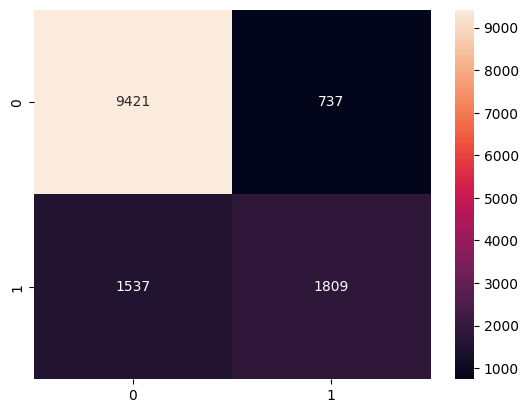

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
# result_df = pd.DataFrame(results, columns=header)
# result_df

In [12]:
# result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')